In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
color1 = np.array([209,83,84])/256
color2 = np.array([80,148,213])/256
color3 = np.array([229,153,129])/256
color4 = np.array([171,216,229])/256
color5 = np.array([94,90,158])/256
color6 = np.array([101,154,111])/256

In [3]:
def overhead(noise):
    return (1 + 0.5*noise) / (1-noise)

In [4]:
noise_level = [0, 0.05, 0.1, 0.15, 0.2 , 0.25, 0.3, 0.35, 0.4, 0.45 ,0.5]
overhead_SDP = overhead(np.array(noise_level))
print(overhead_SDP)

[1.         1.07894737 1.16666667 1.26470588 1.375      1.5
 1.64285714 1.80769231 2.         2.22727273 2.5       ]


# Error mitigation
- depth = 10
- AD noise, noise level q = 0.3

C:\Users\bench\AppData\Local\Temp\ipykernel_29712\891941871.py:11: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(penalty, penalty_overhead, '-o',label='Overhead by VQEM', color=color2, linestyle=':')
C:\Users\bench\AppData\Local\Temp\ipykernel_29712\891941871.py:12: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(penalty, [1.857]*8, '--',label='Overhead by SDP', color='black', linestyle='--')


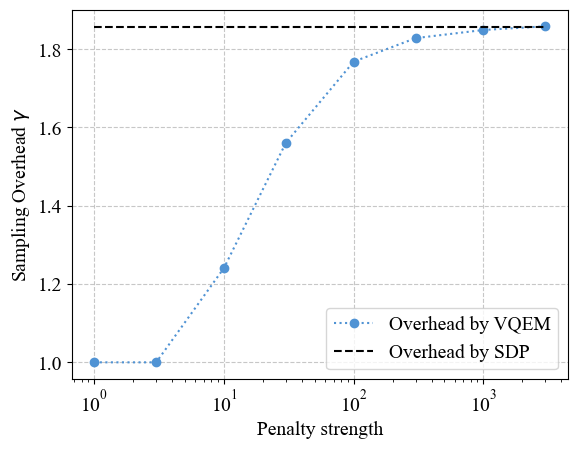

In [ ]:
penalty = [1, 3, 10, 30, 100, 300, 1000, 3000]

penalty_overhead = [1, 1, 1.24099731, 1.56056046, 1.76790524, 1.82785916, 1.8487323, 1.85803246]
penalty_HS = [0.0582, 0.0582, 0.0240, 0.00494, 0.000448, 0.0000495, 0.00000453, 5.9605e-07]


fig, ax = plt.subplots(figsize=(6.4, 4.8))

ax.plot(penalty, penalty_overhead, '-o',label='Overhead by VQEM', color=color2, linestyle=':')
ax.plot(penalty, [1.857]*8, '--',label='Overhead by SDP', color='black', linestyle='--')

plt.xlabel(r'Penalty strength', fontdict={'family' : 'Times New Roman', 'size'   : 14})
plt.ylabel(r'Sampling Overhead $\gamma$', fontdict={'family' : 'Times New Roman', 'size'   : 14})
plt.yscale('linear')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.yticks(fontproperties = 'Times New Roman', size = 14)
plt.xticks(fontproperties = 'Times New Roman', size = 14)
plt.legend(prop={'family' : 'Times New Roman', 'size'   : 14})

# plt.savefig('penalty_overhead.png', dpi=400,bbox_inches='tight')
plt.show()

C:\Users\bench\AppData\Local\Temp\ipykernel_18136\4017537180.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(penalty, penalty_HS, '-o',label='HS norm', color=color2, linestyle=':')


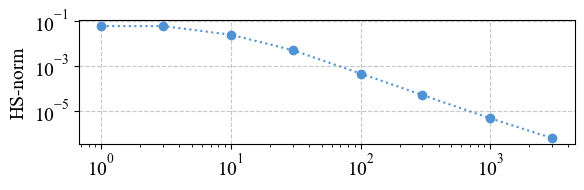

In [ ]:
ratio = 0.25
fig, ax = plt.subplots(figsize=(6.4, 6.4*ratio))

ax.plot(penalty, penalty_HS, '-o',label='HS norm', color=color2, linestyle=':')


ax.set_xscale('log')
ax.set_yscale('log')
plt.ylabel('HS-norm', fontdict={'family' : 'Times New Roman', 'size'   : 14})
plt.grid(True, linestyle='--', alpha=0.7)
plt.yticks(fontproperties = 'Times New Roman', size = 14)
plt.xticks(fontproperties = 'Times New Roman', size = 14)

# plt.savefig('penalty_HS_norm.png', dpi=400, bbox_inches='tight')
plt. show () 

# Virtual VQE

- HeH+ molecular
- gate noise DE 0.01/0.02
- depth 3

In [11]:
import pennylane as qml
from pennylane import numpy as np
dis_list = np.linspace(0.3, 2.5, 221)
ground_energy_list = []
for distance in dis_list:

    symbols = ["He", "H"]
    geometry = np.array([[0.00000000, 0.00000000, -distance],
                        [0.00000000, 0.00000000, distance]])

    molecule = qml.qchem.Molecule(symbols, geometry, charge=1)
    H, qubits = qml.qchem.molecular_hamiltonian(molecule)

    generators = qml.symmetry_generators(H)
    paulixops = qml.paulix_ops(generators, qubits)

    n_electrons = 2
    paulix_sector = qml.qchem.optimal_sector(H, generators, n_electrons)

    H_tapered = qml.taper(H, generators, paulixops, paulix_sector)
    H_tapered_coeffs, H_tapered_ops = H_tapered.terms()
    H_tapered = qml.Hamiltonian(np.real(np.array(H_tapered_coeffs)), H_tapered_ops)

    H_sparse = qml.SparseHamiltonian(H.sparse_matrix(), wires=H.wires)
    H_tapered_sparse = qml.SparseHamiltonian(H_tapered.sparse_matrix(), wires=H_tapered.wires)

    state_tapered = qml.qchem.taper_hf(generators, paulixops, paulix_sector,
                                   num_electrons=n_electrons, num_wires=len(H.wires))
    
    dev = qml.device("lightning.qubit", wires=H_tapered.wires)
    @qml.qnode(dev)
    def circuit():
        qml.BasisState(np.array([1, 1]), wires=H_tapered.wires)
        return qml.state()

    qubit_state = circuit()
    HF_energy = qubit_state.T @ H_tapered.sparse_matrix().toarray() @ qubit_state
    ground_energy_list.append(np.real(HF_energy))

- HeH+ molecular
- gate noise depo DE 0.01, global DE0.02
- depth 5

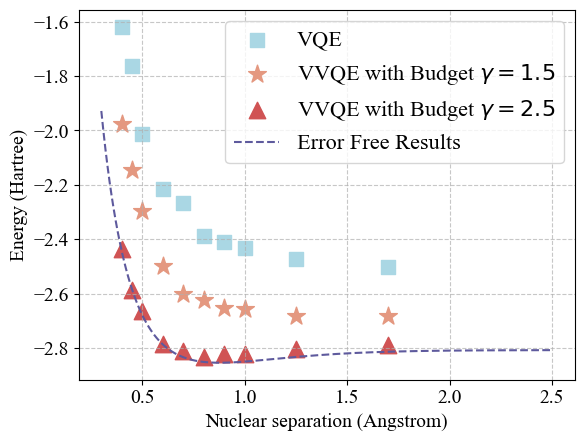

In [ ]:
my_distancne = [0.4, 0.45, 0.5,0.6,0.7,0.8,0.9,1.0,1.25,1.7]

budget_1 = [-1.618426854915561, -1.7634033851362156, -2.014347764708238, -2.214162753299387, -2.266700082969064, -2.3870297200240334, -2.4092085784986947, -2.43294371675648, -2.471704173527817, -2.5026326518539888]
budget_15 = [-1.9753961010951515, -2.1454281498133607, -2.2972168028448325, -2.497033735214472, -2.601331040546258, -2.6245671525107563, -2.652771575104592, -2.656521847051947, -2.6830705165136903, -2.6809861430455477]
budget_25 = [-2.43567108,-2.58629536, -2.66536354,-2.78589293,-2.810794235165451, -2.83268773, -2.8220583673085438, -2.822408140505216, -2.8054479141644793, -2.789995860767154]


plt.scatter(my_distancne, budget_1, color=color4, marker='s', s=100, label='VQE')
plt.scatter(my_distancne, budget_15, color=color3, marker='*', s=180, label=r'VVQE with Budget $\gamma=1.5$')
plt.scatter(my_distancne, budget_25, color=color1, marker='^',s=140, label=r'VVQE with Budget $\gamma=2.5$')
plt.plot(dis_list, ground_energy_list, '--', color=color5, label='Error Free Results')



plt.xlabel('Nuclear separation (Angstrom)', fontdict={'family' : 'Times New Roman', 'size'   : 14})
plt.ylabel('Energy (Hartree)', fontdict={'family' : 'Times New Roman', 'size'   : 14})
plt.grid(True, linestyle='--', alpha=0.7)
plt.yticks(fontproperties = 'Times New Roman', size = 14)
plt.xticks(fontproperties = 'Times New Roman', size = 14)
plt.legend(prop={'family' : 'Times New Roman', 'size'   : 16})

# plt.savefig('VVQE_HeH+.png', dpi=400)
plt.show()

# QEM
- target noise 0.2 depo
- local gate noise depo DE 0.01, global gate  DE 0.02

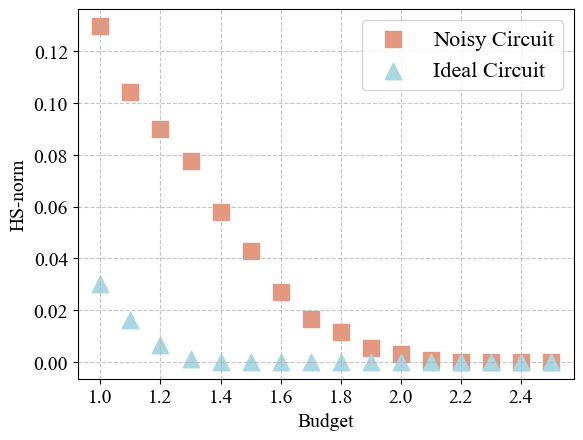

In [5]:
budget_list = np.linspace(1.0,2.5, 16)
cost_list_with_noise = [0.12979483604431152, 0.10425114631652832, 0.09013450145721436, 0.07766413688659668, 0.05801069736480713, 0.04298532009124756, 0.0271700590133667, 0.016680598258972168, 0.011723637580871582, 0.005405068397521973, 0.0031843185424804688, 0.0007063150405883789, 0.00011456012725830078, 0.0, 1.1920928955078125e-07, 0.0]
cost_list_without_noise = [0.030022025108337402, 0.016143441200256348, 0.0065354108810424805, 0.001225590705871582, 2.384185791015625e-07, 1.1920928955078125e-07, 2.384185791015625e-07, 2.384185791015625e-07, 4.76837158203125e-07, 2.384185791015625e-07, 2.384185791015625e-07, 2.384185791015625e-07, 1.1920928955078125e-07, 0.0, 1.1920928955078125e-07, 1.1920928955078125e-07]
plt.scatter(budget_list, cost_list_with_noise, color=color3, marker='s', s=140, label='Noisy Circuit')
plt.scatter(budget_list, cost_list_without_noise, color=color4, marker='^', s=140, label='Ideal Circuit')


plt.xlabel('Budget', fontdict={'family' : 'Times New Roman', 'size'   : 14})
plt.ylabel('HS-norm', fontdict={'family' : 'Times New Roman', 'size'   : 14})
plt.grid(True, linestyle='--', alpha=0.7)
plt.yticks(fontproperties = 'Times New Roman', size = 14)
plt.xticks(fontproperties = 'Times New Roman', size = 14)
plt.legend(prop={'family' : 'Times New Roman', 'size'   : 16})

plt.savefig('norm_vs_budget.png', dpi=400)
plt.show()
